<a href="https://colab.research.google.com/github/lcbjrrr/algojust/blob/main/Pmpt01_confirmation_outlier_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Confirmation and Outlier bias


Download: [Classes-oks.csv](https://raw.githubusercontent.com/lcbjrrr/algojust/refs/heads/main/Classes%20-%20oks.csv)

- **Confirmation bias**: The tendency to search for, interpret, favor, and recall information that confirms one's existing beliefs or values. This can lead to selective data analysis and distorted findings. For instance, a teacher who believes boys are better at math might unconsciously call on them more frequently, reinforcing their belief.

- **Outlier bias**: Outliers or anomalies in the data can skew the results, especially when using averages. Using the median instead of the average can help mitigate this.
Measurement bias: Occurs when data collected for training differs from data collected in the real world or when faulty measurements distort data. This can result in lower accuracy for models.


*The data used herein is for illustrative purposes only and does not reflect actual real-world data*

> Read the file 'Classes - oks.csv' and show the dataframe

In [ ]:
import pandas as pd
df = pd.read_csv('/content/Classes - oks.csv')
df

,Klevel,girl,math,lang,read,write
0,1,0,63,47,54,52
1,1,1,72,69,76,66
2,1,0,68,51,57,46
3,1,1,65,67,76,72
4,1,0,69,50,52,46
...,...,...,...,...,...,...
98,4,0,99,50,55,49
99,5,0,99,60,65,59
100,6,0,99,50,55,49
101,7,0,99,60,65,59


#### Are boys (on average) better than girls at Math?



> Create a aggregated table grouping by Gender the Average Math grade

In [ ]:
gender_math_avg = df.groupby('girl')['math'].mean().reset_index()
gender_math_avg['girl'] = gender_math_avg['girl'].map({0: 'Boys', 1: 'Girls'})
gender_math_avg.rename(columns={'girl': 'Gender', 'math': 'Average Math Grade'}, inplace=True)
gender_math_avg

,Gender,Average Math Grade
0,Boys,66.896552
1,Girls,66.266667


> Create a bar chart comparing those

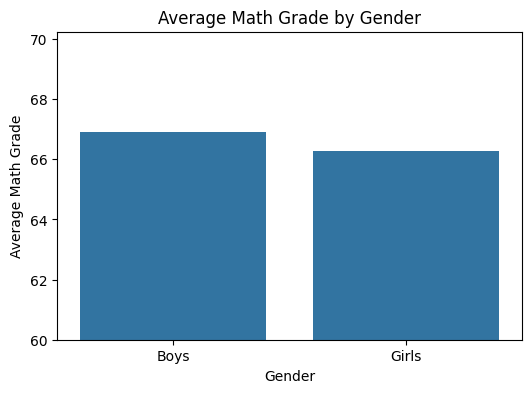

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.barplot(x='Gender', y='Average Math Grade', data=gender_math_avg)
plt.title('Average Math Grade by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Math Grade')
plt.ylim(ymin=60) # Set a minimum y-limit to better show the difference
plt.show()

*Observe that the bar for boys (Gender 0) is slightly taller than the bar for girls (Gender 1). This visually represents that, according to this dataset, boys have a marginally higher average Math grade (approximately 66.9) compared to girls (approximately 66.3)*


#### How about if break it down by grade/K-level?



> Create now a aggregated table grouped by KLevel and then gender, calculating the average for the math grade

In [ ]:
klevel_gender_math_avg = df.groupby(['Klevel', 'girl'])['math'].mean().reset_index()
klevel_gender_math_avg['girl'] = klevel_gender_math_avg['girl'].map({0: 'Boys', 1: 'Girls'})
klevel_gender_math_avg.rename(columns={'girl': 'Gender', 'math': 'Average Math Grade'}, inplace=True)
klevel_gender_math_avg

,Klevel,Gender,Average Math Grade
0,1,Boys,71.500000
1,1,Girls,66.000000
2,2,Boys,67.500000
3,2,Girls,66.600000
4,3,Boys,66.166667
5,3,Girls,65.200000
6,4,Boys,67.000000
7,4,Girls,68.200000
8,5,Boys,65.166667
9,5,Girls,66.400000


In [ ]:
klevel_gender_math_avg = df.groupby(['Klevel', 'girl'])['math'].mean().reset_index()
klevel_gender_math_avg

,Klevel,girl,math
0,1,0,71.500000
1,1,1,66.000000
2,2,0,67.500000
3,2,1,66.600000
4,3,0,66.166667
5,3,1,65.200000
6,4,0,67.000000
7,4,1,68.200000
8,5,0,65.166667
9,5,1,66.400000


> Using seaborn, create a bar chart comparing those

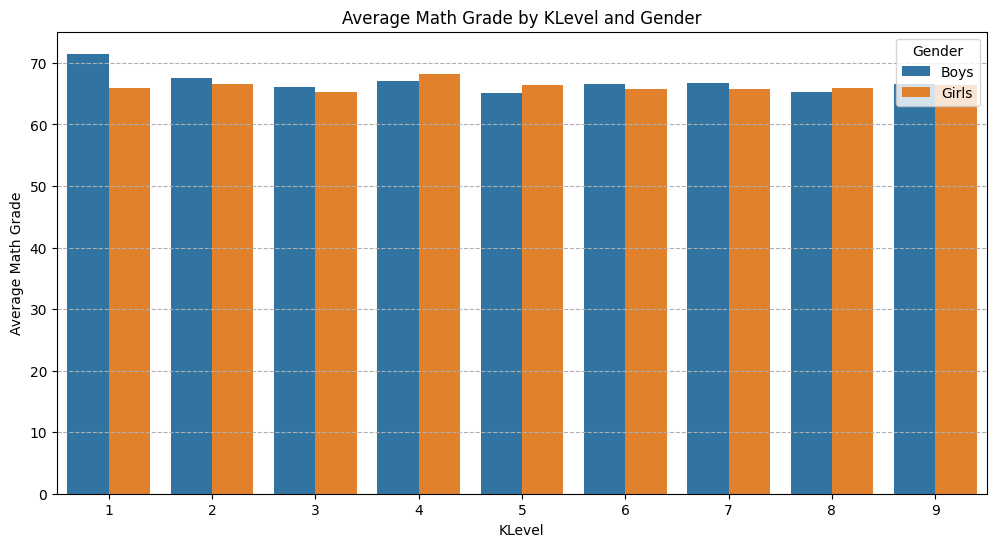

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

klevel_gender_math_avg_plot = klevel_gender_math_avg.copy()
klevel_gender_math_avg_plot['girl'] = klevel_gender_math_avg_plot['girl'].map({0: 'Boys', 1: 'Girls'})

plt.figure(figsize=(12, 6))
sns.barplot(x='Klevel', y='math', hue='girl', data=klevel_gender_math_avg_plot)
plt.title('Average Math Grade by KLevel and Gender')
plt.xlabel('KLevel')
plt.ylabel('Average Math Grade')
plt.legend(title='Gender')
plt.grid(axis='y', linestyle='--')
plt.show()

*While the initial overall average showed boys with a marginally higher score, this granular analysis by K-level reveals that the performance varies. Neither gender consistently outperforms the other across all K-levels by a large margin, and there are reversals in who scores higher at different educational stages. The differences are often quite small, indicating that other factors might be more influential than gender at specific K-levels.*


<Axes: xlabel='Klevel', ylabel='math'>

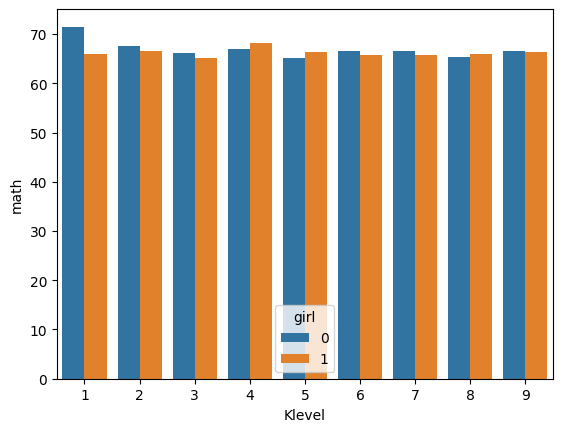

In [ ]:
sns.barplot(x='Klevel', y='math', hue='girl', data=klevel_gender_math_avg)

#### Is there a chance that particular boy affects the average greatly (outliers)??



> Create a boxplot for the math grade, broken down by Klevel and separete by color (hue) on gender

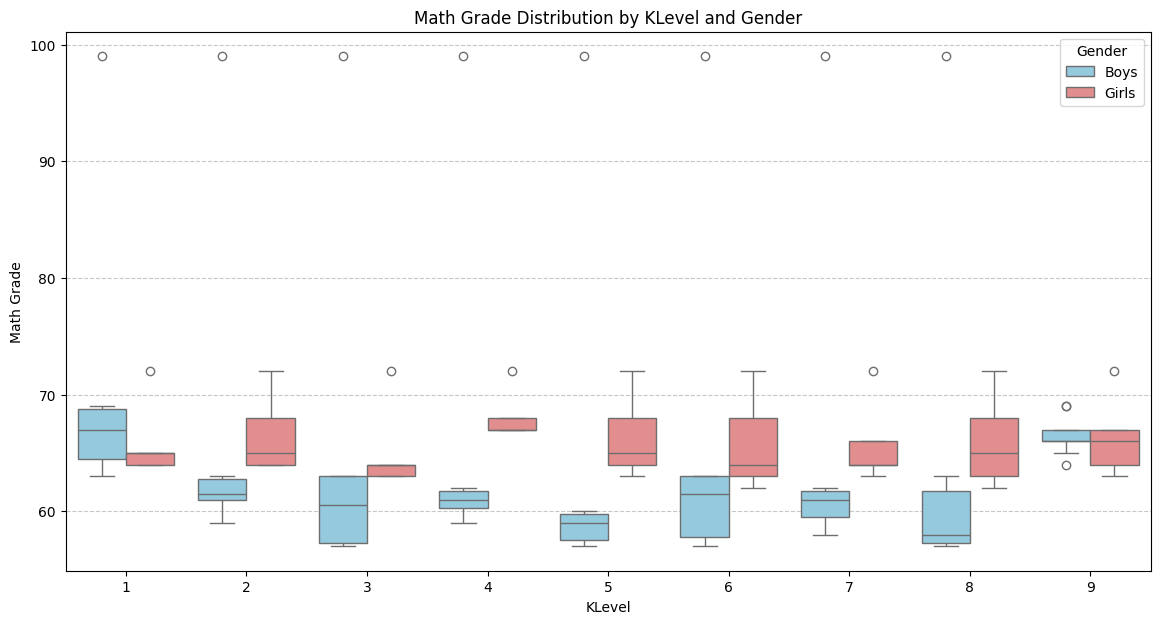

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy of the DataFrame for plotting to avoid modifying the original df
df_plot = df.copy()
df_plot['Gender'] = df_plot['girl'].map({0: 'Boys', 1: 'Girls'})

plt.figure(figsize=(14, 7))
sns.boxplot(x='Klevel', y='math', hue='Gender', data=df_plot, palette={'Boys': 'skyblue', 'Girls': 'lightcoral'})
plt.title('Math Grade Distribution by KLevel and Gender')
plt.xlabel('KLevel')
plt.ylabel('Math Grade')
plt.legend(title='Gender')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

*For many K-levels, particularly K-level 1 (boys), K-level 4 (boys and girls), K-level 5 (boys), K-level 6 (boys), and K-level 7 (boys), there are grades clustered around 99-100. These are the most prominent outliers, indicating students with exceptionally high math scores. While these could be genuine top performers, their presence can disproportionately influence average calculations*.

*Both boys and girls have outliers. For instance, in K-level 4, both genders show high-scoring outliers. However, in some other K-levels like 1, 5, 6, and 7, the visible outliers predominantly belong to boys. This doesn't necessarily mean girls don't have high performers, but perhaps fewer extreme high scores that fall outside the general distribution for their group in those specific K-levels*.


<Axes: xlabel='Klevel', ylabel='math'>

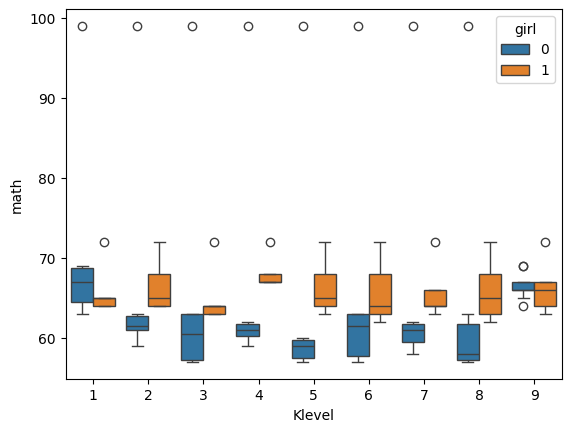

In [ ]:
sns.boxplot(x='Klevel', y='math', hue='girl', data=df)

#### What if we take out those outlier?



> Create a new dataframe filtering out any math grade above 98

In [ ]:
df_filtered = df[df['math'] <= 98]
df_filtered

,Klevel,girl,math,lang,read,write
0,1,0,63,47,54,52
1,1,1,72,69,76,66
2,1,0,68,51,57,46
3,1,1,65,67,76,72
4,1,0,69,50,52,46
...,...,...,...,...,...,...
90,9,0,69,53,52,52
91,9,1,67,67,76,71
92,9,0,64,48,56,51
93,9,0,67,47,55,47


> Using seaborn, create a bar chart comparing those

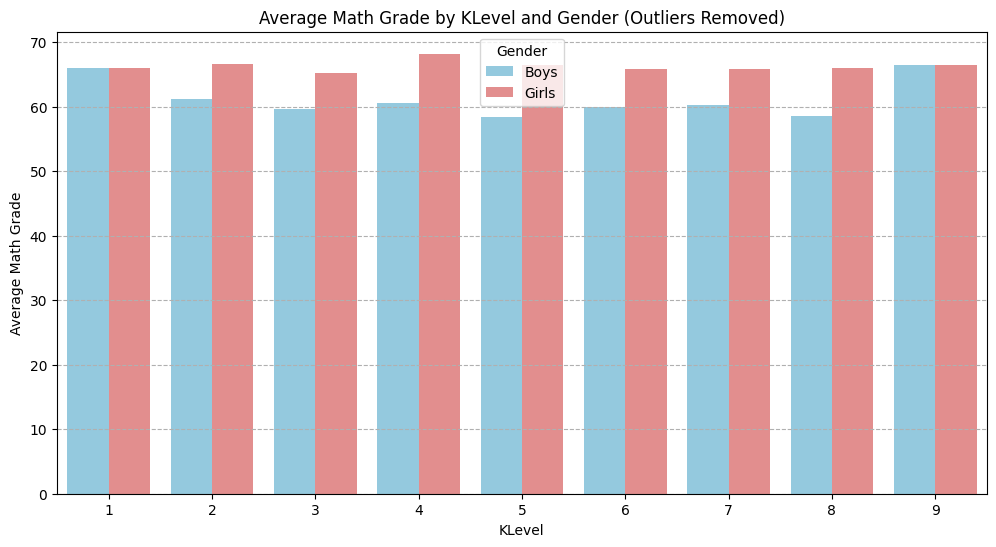

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

klevel_gender_math_avg_filtered = df_filtered.groupby(['Klevel', 'girl'])['math'].mean().reset_index()
klevel_gender_math_avg_filtered['girl'] = klevel_gender_math_avg_filtered['girl'].map({0: 'Boys', 1: 'Girls'})
klevel_gender_math_avg_filtered.rename(columns={'girl': 'Gender', 'math': 'Average Math Grade'}, inplace=True)

plt.figure(figsize=(12, 6))
sns.barplot(x='Klevel', y='Average Math Grade', hue='Gender', data=klevel_gender_math_avg_filtered, palette={'Boys': 'skyblue', 'Girls': 'lightcoral'})
plt.title('Average Math Grade by KLevel and Gender (Outliers Removed)')
plt.xlabel('KLevel')
plt.ylabel('Average Math Grade')
plt.legend(title='Gender')
plt.grid(axis='y', linestyle='--')
plt.show()

or...

    Klevel  girl  math
0        1     0  66.0
1        1     1  66.0
2        2     0  61.2
3        2     1  66.6
4        3     0  59.6
5        3     1  65.2
6        4     0  60.6
7        4     1  68.2
8        5     0  58.4
9        5     1  66.4
10       6     0  60.0
11       6     1  65.8
12       7     0  60.2
13       7     1  65.8
14       8     0  58.6
15       8     1  66.0
16       9     0  66.5
17       9     1  66.4


<Axes: xlabel='Klevel', ylabel='math'>

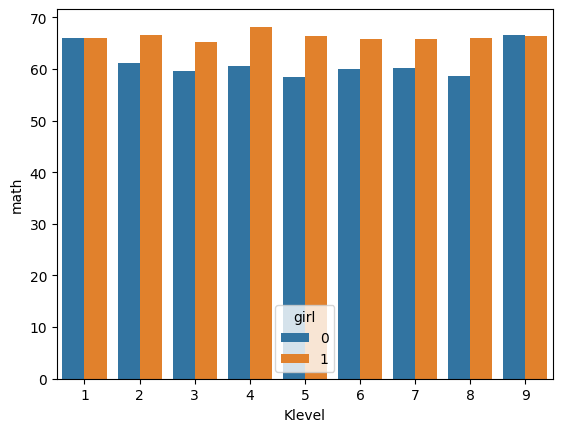

In [ ]:
klevel_gender_math_avg_filtered = df_filtered.groupby(['Klevel', 'girl'])['math'].mean().reset_index()
print(klevel_gender_math_avg_filtered)
sns.barplot(x='Klevel', y='math', hue='girl', data=klevel_gender_math_avg_filtered)


#### Are there still outliers? Are they really outliers or simply top performers? Are they boys or girls now?



> Create a boxplot for the math grade, broken down by Klevel and separete by color (hue) on gender

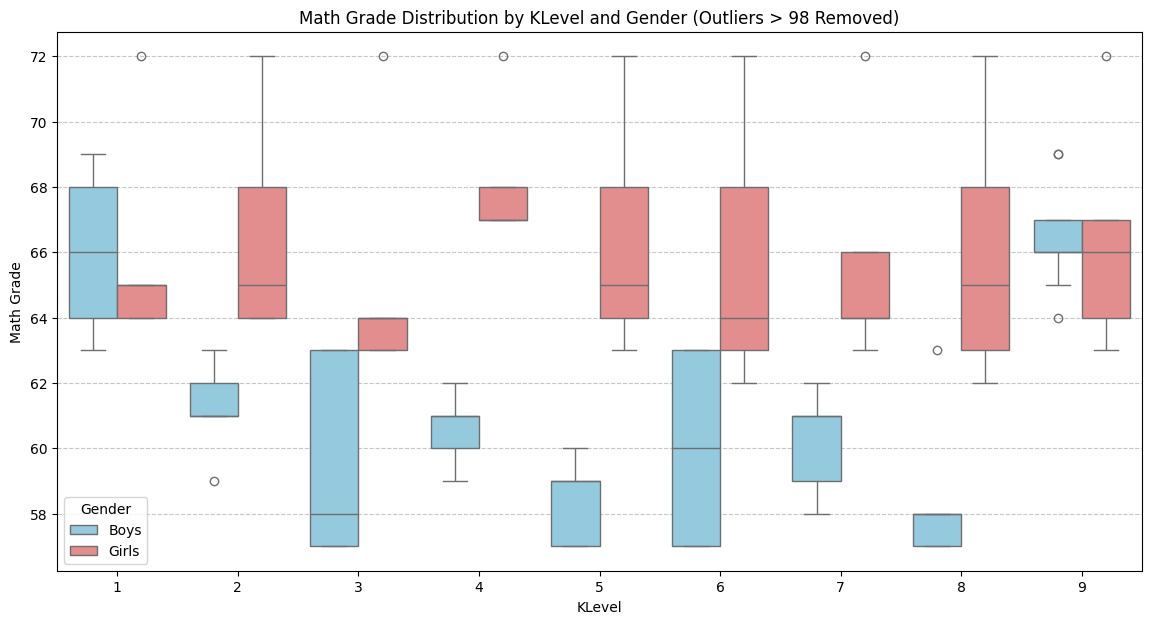

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy of the filtered DataFrame for plotting to avoid modifying it directly
df_filtered_plot = df_filtered.copy()
df_filtered_plot['Gender'] = df_filtered_plot['girl'].map({0: 'Boys', 1: 'Girls'})

plt.figure(figsize=(14, 7))
sns.boxplot(x='Klevel', y='math', hue='Gender', data=df_filtered_plot, palette={'Boys': 'skyblue', 'Girls': 'lightcoral'})
plt.title('Math Grade Distribution by KLevel and Gender (Outliers > 98 Removed)')
plt.xlabel('KLevel')
plt.ylabel('Math Grade')
plt.legend(title='Gender')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

*Looking closely, some of these new, lower-value outliers appear for both boys and girls. For example, in K-level 1, there's a boy with a score significantly lower than his peers. In K-level 2, some boys are scoring quite low. For girls, some K-levels (e.g., K-level 5, 8) also show individual low scores that might be considered outliers.*


<Axes: xlabel='Klevel', ylabel='math'>

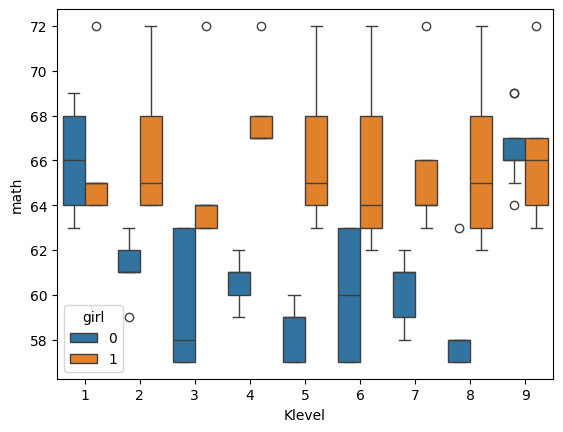

In [ ]:
sns.boxplot(x='Klevel', y='math', hue='girl',data=df_filtered)

## Activity: Confirmation and Outlier bias



**Problem**
Search Kaggle for a dataset containing a quantifiable characteristic and identifiable groupings/categories and create your ownhypothesis on comparing this measurable characteristic between the groups within a dataset (for example, people smoke more in Europe than in the USA). Then:
- *Assumption Validation*: Determine if your initial hypothesis holds true by comparing a measurable characteristic between your chosen groups.
- *Sub-level Breakdown*: Investigate variations by examining the characteristic at more granular sub-levels within your main categories (e.g., breakdown by countries).
- *Outlier Handling*: Identify and remove outliers from your data, then re-perform the analysis to see how the results change without their influence.

**Conclusion and Bias Assessment**
Formulate a conclusion about your assumption's confirmation based on both analyses (with and without outliers), and critically discuss the impact of outliers and any potential confirmation bias in your findings.
